# Train CNN model with ImageDataGenerator and Split-Folder

In [5]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator

### ImageDataGenerator()
#### Used to load and preprocess images for training
- Reads images from folders
- Resizes images to a fixed size
- Normalizes pixel values (e.g., 0–255 → 0–1)
- Can perform data augmentation :
  - Rotation
  - Zoom
  - Flip
  - Shift
  - Shear
- Generates image batches during training
- Helps reduce overfitting by creating modified versions of images

### split-folders
#### Used to split a dataset into train, validation, and test folders automatically.

- Takes images from one dataset folder
- Creates :
   - train/
   - val/
   - test/
- Randomly distributes images according to given ratios
- Saves time compared to manually splitting files

In [16]:
# pip install split-folders

In [19]:
# pip install scipy

In [55]:
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 20

### Data splitting
- ImageDataGenerator cant split data into train, val only
- So to split data into train, val, test 3 parts we have to use another package call split_folder
- Run in cmd in training folder ***split_folders --output processed_data --ratio .7 .1 .2 -- data***, decimal order is train, val, test

#### Training dataset

In [25]:
# After splitting intial data folders as above run this

# defining a recipe / transformation rules
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True, # Randomly flips some images left ↔ right
    rotation_range=10 # Randomly rotates images between -10° and +10°
)

# flow_from_directory = PIPELINE BUILDER
# Reads images > Uses train_datagen rules > Batch system is created > Class labels are created ferom folder name > 
# only creates a generator object and prepares instructions
train_generator = train_datagen.flow_from_directory(
    'processed_data/train',
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse', # categorical, binary, raw, ...
   # save_to_dir="AugmentedImages"
)

Found 1506 images belonging to 3 classes.


In [24]:
# Whenever someone asks for a batch, onyly execute the above rules, here we are going to print something that belongs to train_generator, 
# so it now execute batch wise here we stopped in first iteration so it only create first bath so in saved folder(AugmentedImages) only see 32 imgs 
for img_batch, label_batch in train_generator:
    print(img_batch[0])
    break

[[[0.5156965  0.5039318  0.5470691 ]
  [0.46174136 0.44997665 0.4931139 ]
  [0.48785037 0.47608566 0.5192229 ]
  ...
  [0.56601083 0.5581677  0.6091481 ]
  [0.5875897  0.57974654 0.63072693]
  [0.6215789  0.61373574 0.6647161 ]]

 [[0.48170733 0.46994263 0.5130799 ]
  [0.4474019  0.4356372  0.47877446]
  [0.5313339  0.5195692  0.5627065 ]
  ...
  [0.6146619  0.60681874 0.6577991 ]
  [0.60393816 0.596095   0.6470754 ]
  [0.5959425  0.58809936 0.63907975]]

 [[0.47513488 0.46337017 0.50650746]
  [0.41054907 0.39878437 0.44192162]
  [0.47616994 0.46440524 0.50754255]
  ...
  [0.64713293 0.6392898  0.6902702 ]
  [0.6273195  0.6194764  0.67045677]
  [0.6049551  0.59711194 0.6480923 ]]

 ...

 [[0.6836542  0.66404635 0.68757576]
  [0.6414042  0.62179637 0.6453258 ]
  [0.5029358  0.48332798 0.5068574 ]
  ...
  [0.7105512  0.6987865  0.7262375 ]
  [0.7112045  0.6994398  0.7268908 ]
  [0.71176136 0.69999665 0.7274476 ]]

 [[0.6051096  0.58550173 0.60903114]
  [0.5364863  0.5168785  0.5404079 ]


#### Val datset

In [26]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True, # Randomly flips some images left ↔ right
    rotation_range=10 # Randomly rotates images between -10° and +10°
)

val_generator = val_datagen.flow_from_directory(
    'processed_data/val',
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse', # categorical, binary, raw, ...
   # save_to_dir="AugmentedImages"
)

Found 215 images belonging to 3 classes.


In [27]:
test_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True, # Randomly flips some images left ↔ right
    rotation_range=10 # Randomly rotates images between -10° and +10°
)

test_generator = test_datagen.flow_from_directory(
    'processed_data/test',
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse', # categorical, binary, raw, ...
   # save_to_dir="AugmentedImages"
)

Found 431 images belonging to 3 classes.


### CNN model

In [56]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten
    # layers.Flatten(), # Old architecture

    # Modern
    layers.GlobalAveragePooling2D(),

    # Dense layer input is 115,200 these all weights connects all 64 neurons (Dense layer = Fully connected layer) 115,200 x 64 + 64 bias = 7,372,864
    layers.Dense(units=32, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

In [57]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)                   │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 97,475 (380.76 KB)

 Trainable params: 97,475 (380.76 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [61]:
# if i set steps_per_epoch as 10 then modEl see onyl 32x10 images other skip
# if use 50, After 1506 images -> it starts repeating images again

history = model.fit(
    train_generator, # gives: images in batches, labels in batches
    steps_per_epoch= len(train_generator), # howe many batches per epoch 1506/32 = 47.06
    batch_size=32,
    validation_data=val_generator,
    validation_steps=6,
    epochs=EPOCHS, # Entire dataset is seen 50 times
    verbose=1,
)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.4861 - loss: 0.8942 - val_accuracy: 0.4688 - val_loss: 0.8965
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.5452 - loss: 0.8506 - val_accuracy: 0.6354 - val_loss: 0.8018
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6733 - loss: 0.7153 - val_accuracy: 0.6719 - val_loss: 0.7064
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7749 - loss: 0.5710 - val_accuracy: 0.9219 - val_loss: 0.3983
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8745 - loss: 0.3351 - val_accuracy: 0.8698 - val_loss: 0.2999
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8758 - loss: 0.3193 - val_accuracy: 0.9167 - val_loss: 0.2146
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9442 - loss: 0.1887 - val_accuracy: 0.9167 - val_loss: 0.2290
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9595 - loss: 0.1354 - val_accuracy: 0.9531 - val_loss:

In [62]:
scores = model.evaluate(test_generator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 641ms/step - accuracy: 0.9675 - loss: 0.0812


In [63]:
history.params

{'verbose': 1, 'epochs': 20, 'steps': 48}

In [64]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [65]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

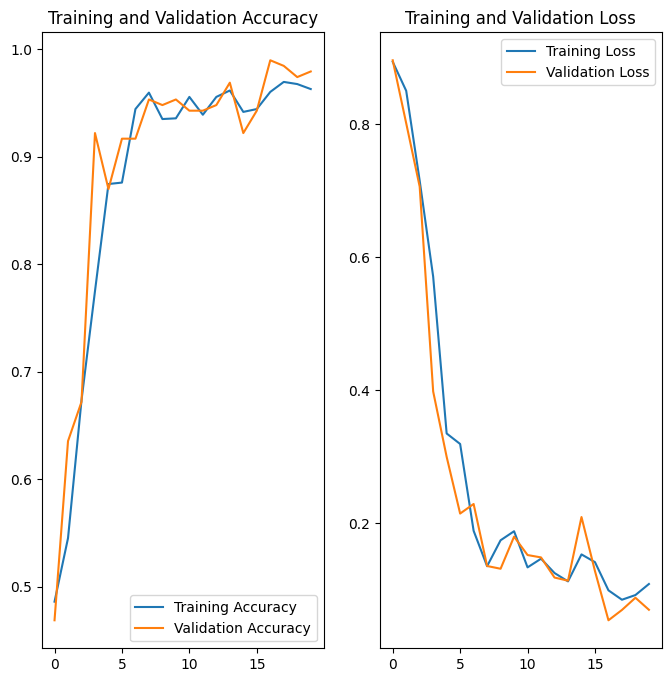

In [66]:
# Accuracy 
plt.figure(figsize=(8,8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label="Training Accuracy")
plt.plot(range(EPOCHS), val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

# LOSS
plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label="Training Loss")
plt.plot(range(EPOCHS), val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

### Save as h5

In [67]:
model.save('../saved_models/h5/potato_model.h5')